In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

import torch 
import torch.nn as nn
import torch.optim as optim 
import torchvision
from torchvision import datasets , transforms 
from torch.utils.data import DataLoader

In [2]:
train_transforms = transforms.Compose ([

    transforms.Resize((224,224)), 
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(25), 
    transforms.ToTensor(), 
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose ([

    transforms.Resize((224,224)), 
    transforms.ToTensor(), 
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [3]:
train_data = datasets.ImageFolder(r'C:\Users\mishr\Deep Learning\waste-classification-cnn-project-main\waste-classification-data\DATASET\TRAIN', transform=train_transforms)
test_data = datasets.ImageFolder(r'C:\Users\mishr\Deep Learning\waste-classification-cnn-project-main\waste-classification-data\DATASET\TEST', transform=test_transforms)

In [4]:
len(train_data), len(test_data)

(22564, 2514)

### Data Loader

In [5]:
batch_size = 32

train_loader = DataLoader(train_data , batch_size = batch_size , shuffle=True)
test_loader = DataLoader(test_data , batch_size = batch_size , shuffle=True)

In [6]:
for i, (images,labels) in enumerate(train_loader): 
    print(images.shape)
    print(labels.shape)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [7]:
### Displaying some Sample data

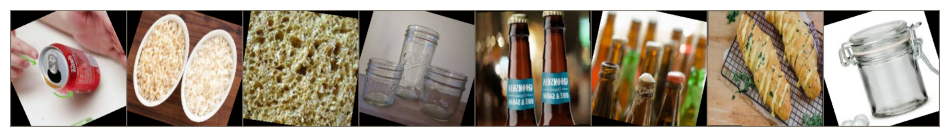

Labels for the images above: [1 0 0 1 1 1 0 1]


In [8]:
dataiter = iter(train_loader)
images, labels = next(dataiter)

def imshow(img):
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    img = inv_normalize(img)
    
    npimg = img.numpy()
    npimg = np.clip(npimg, 0, 1)
    
    plt.figure(figsize=(12, 6))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

imshow(torchvision.utils.make_grid(images[:8]))

print("Labels for the images above:", labels[:8].numpy())

In [9]:
### CNN architecture

In [10]:
512*7*7 

25088

In [11]:
class wasteCNN(nn.Module): 
    def __init__(self): 
        super().__init__()
        self.network = nn.Sequential (

            nn.Conv2d(3,32 , kernel_size=(3,3), stride=1 , padding="same"), # 32,224,224
            nn.BatchNorm2d(32), 
            nn.ReLU(), 
            nn.MaxPool2d(kernel_size=(2,2), stride=(2,2)), # 32,112,112

            nn.Conv2d(32,64 , kernel_size=(3,3), stride=1 , padding="same"), # 64,112,112 
            nn.BatchNorm2d(64), 
            nn.ReLU(), 
            nn.MaxPool2d(kernel_size=(2,2), stride=(2,2)), # 64,56,56
            
            nn.Conv2d(64,128 , kernel_size=(3,3), stride=1 , padding="same"), # 128,56,56 
            nn.BatchNorm2d(128), 
            nn.ReLU(), 
            nn.MaxPool2d(kernel_size=(2,2), stride=(2,2)), # 128,28,28

            nn.Conv2d(128,256 , kernel_size=(3,3), stride=1 , padding="same"), # 256,28,28 
            nn.BatchNorm2d(256), 
            nn.ReLU(), 
            nn.MaxPool2d(kernel_size=(2,2), stride=(2,2)), # 256,14,14

            nn.Conv2d(256,512 , kernel_size=(3,3), stride=1 , padding="same"), # 512,14,14 
            nn.BatchNorm2d(512), 
            nn.ReLU(), 
            nn.MaxPool2d(kernel_size=(2,2), stride=(2,2)), # 512,7,7
        )

        self.fc_layers = nn.Sequential (

            nn.Flatten(), 

            nn.Linear(512*7*7 , 600), 
            nn.ReLU(), 
            nn.Dropout(0.5),

            nn.Linear(600,120), 
            nn.ReLU(), 
            nn.Dropout(0.3),

            nn.Linear(120,1), 

            nn.Sigmoid()
        )


    def forward(self,x): 
        x = self.network(x)
        x = self.fc_layers(x)
        return x


if torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU")
else : 
    device = torch.device("cpu")
    print("CPU")

model = wasteCNN().to(device)

GPU


In [12]:
learning_rate = 0.001

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr = learning_rate)
lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

In [13]:
epochs = 10
best_val_loss = float('inf')


for epoch in range (epochs): 
    model.train()
    running_train_loss = 0 

    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()


    if (i+1) % 100 == 0 : 
        print(f"Epoch [{epoch+1}/{epochs}, Loss:- {loss.item():.4f}]")

    model.eval()
    running_val_loss = 0.0
    correct_preds = 0
    total_preds = 0
    
    with torch.no_grad(): 
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)
    
            outputs = model(images)
            val_loss = criterion(outputs, labels)
            running_val_loss += val_loss.item()

                
            predicted = torch.round(outputs) 
            total_preds += labels.size(0)
            correct_preds += (predicted == labels).sum().item()
    
    avg_val_loss = running_val_loss / len(test_loader)
    accuracy = (correct_preds / total_preds) * 100

    lr_scheduler.step(avg_val_loss)
        
    print(f"Epoch {epoch+1} , Val Loss: {avg_val_loss:.4f} , Accuracy: {accuracy:.2f}%")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_waste_classifier.pt')
        print(f"New best model saved with Val Loss: {best_val_loss:.4f}")

Epoch 1 , Val Loss: 0.4341 , Accuracy: 85.84%
New best model saved with Val Loss: 0.4341
Epoch 2 , Val Loss: 0.2845 , Accuracy: 88.15%
New best model saved with Val Loss: 0.2845
Epoch 3 , Val Loss: 0.3394 , Accuracy: 86.04%
Epoch 4 , Val Loss: 0.2776 , Accuracy: 87.31%
New best model saved with Val Loss: 0.2776
Epoch 5 , Val Loss: 0.2557 , Accuracy: 89.66%
New best model saved with Val Loss: 0.2557
Epoch 6 , Val Loss: 0.2484 , Accuracy: 90.21%
New best model saved with Val Loss: 0.2484
Epoch 7 , Val Loss: 0.2421 , Accuracy: 91.25%
New best model saved with Val Loss: 0.2421
Epoch 8 , Val Loss: 0.2805 , Accuracy: 88.11%
Epoch 9 , Val Loss: 0.2387 , Accuracy: 91.29%
New best model saved with Val Loss: 0.2387
Epoch 10 , Val Loss: 0.2165 , Accuracy: 91.37%
New best model saved with Val Loss: 0.2165


In [14]:
### MODEL EVALUATION 

In [15]:
from sklearn.metrics import confusion_matrix, classification_report

Running evaluation on the test set...


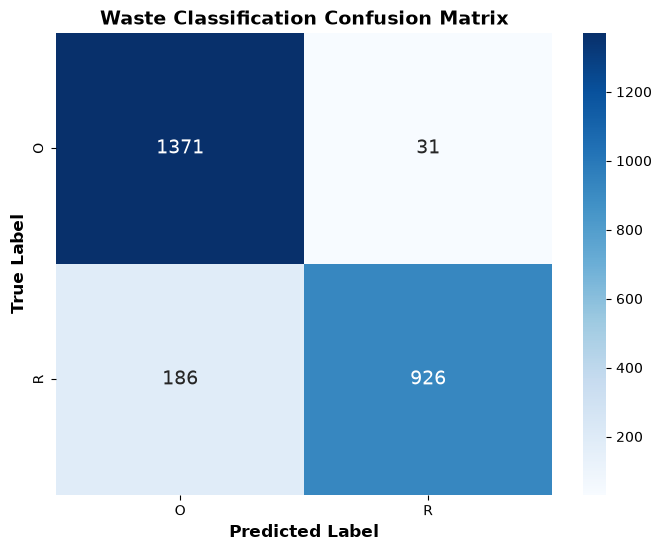

              precision    recall  f1-score   support

           O       0.88      0.98      0.93      1402
           R       0.97      0.83      0.90      1112

    accuracy                           0.91      2514
   macro avg       0.92      0.91      0.91      2514
weighted avg       0.92      0.91      0.91      2514



In [18]:
model.eval()

all_preds = []
all_labels = []

print("Running evaluation on the test set...")

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        
        labels_tensor = labels.float().unsqueeze(1).to(device)
        
        outputs = model(images)
        
        
        predicted = torch.round(outputs)
        
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels_tensor.cpu().numpy())

all_preds = np.array(all_preds).flatten()
all_labels = np.array(all_labels).flatten()

class_names = test_data.classes

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 14})

plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('Waste Classification Confusion Matrix', fontsize=14, fontweight='bold')
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names))